# La cohorte de validación externa

## *Gait in Parkinson's Disease Database* — Entrega P1

Este cuaderno caracteriza la segunda cohorte del proyecto. No es un análisis redundante del primero: `gaitpdb` cumple un papel específico que `gaitndd` no puede cumplir.

En el cuaderno principal quedó establecido que el grupo control de `gaitndd` es **27 años más joven** que el grupo con Parkinson, un confusor que el diseño de ese dataset no permite corregir. La conclusión sobre la pregunta de investigación 3 quedó, por eso, en suspenso.

`gaitpdb` resuelve exactamente ese problema: sus grupos **sí están pareados por edad**. Si la señal que separa Parkinson de control sobrevive en una cohorte donde la edad no discrimina, entonces la edad no era lo que el modelo estaba aprendiendo.

Los objetivos de este cuaderno son tres:

1. Caracterizar la cohorte y verificar el pareamiento por edad.
2. Documentar sus defectos de formato y sus fugas de etiqueta antes de usarla.
3. Establecer qué particionamiento exige su estructura de grabaciones repetidas.

In [1]:
import subprocess
import sys
from pathlib import Path

REPOSITORIO = "https://github.com/jeraldinedione/proyecto-machine-learning.git"


def raiz_del_proyecto(inicio: Path) -> Path:
    for carpeta in [inicio, *inicio.parents]:
        if (carpeta / "src" / "gait").is_dir():
            return carpeta
    raise FileNotFoundError("No se encontró la raíz del proyecto")


if "google.colab" in sys.modules:
    if not Path("marcha").exists():
        subprocess.run(["git", "clone", "--quiet", REPOSITORIO, "marcha"], check=True)
    RAIZ = Path("marcha").resolve()
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "--quiet", "-r", str(RAIZ / "requirements.txt")],
        check=True,
    )
else:
    RAIZ = raiz_del_proyecto(Path.cwd())

sys.path.insert(0, str(RAIZ / "src"))
print(RAIZ)

/Users/nllerenas/UTEC/2026-1/machine-learning/chiwawa/proyecto


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from gait import config, download, gaitndd, gaitpdb, plots

download.fetch(config.GAITPDB)
plots.use_project_style()

pd.set_option("display.width", 180)
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

---

## 1. Protocolo y estructura

Cada participante caminó aproximadamente dos minutos con **ocho sensores de fuerza bajo cada pie**, muestreados a 100 Hz. Frente a los dos canales de `gaitndd`, aquí hay 16 canales más las dos sumas por pie: en lugar de una serie de intervalos ya derivada, se dispone de la distribución espacial de la fuerza plantar.

La base reúne **tres estudios independientes**, identificados por el prefijo del registro.

In [3]:
for codigo, descripcion in gaitpdb.STUDY_LABELS.items():
    print(f"{codigo}   {descripcion}")

Ga   doble tarea (Yogev et al., 2005)
Ju   estimulacion auditiva ritmica (Hausdorff et al., 2007)
Si   caminadora (Frenkel-Toledo et al., 2005)


Los tres protocolos son distintos: marcha con doble tarea, marcha con estimulación auditiva rítmica y marcha en caminadora. **El estudio de origen es un confusor de protocolo** y debe controlarse, igual que se controla el sujeto.

In [4]:
registros = gaitpdb.record_index()
print(f"grabaciones: {len(registros)}   sujetos con grabación: {registros.subject.nunique()}")
registros.head(3)

grabaciones: 306   sujetos con grabación: 165


,record,subject,study,group,subject_number,walk,dual_task
0,GaCo01_01,GaCo01,Ga,control,1,1,False
1,GaCo02_01,GaCo02,Ga,control,2,1,False
2,GaCo02_02,GaCo02,Ga,control,2,2,False


---

## 2. La metadata tampoco se puede leer de frente

`gaitndd` exigía un parser propio. `gaitpdb` también, por un motivo distinto: sus filas tienen un número **variable** de tabuladores sobrantes al final, de modo que `pd.read_csv` no falla silenciosamente sino que se cae.

In [5]:
ruta = config.GAITPDB.path / "demographics.txt"

try:
    pd.read_csv(ruta, sep="\t")
except pd.errors.ParserError as error:
    print("pd.read_csv falla:", error)

print()
conteo = pd.Series(
    [linea.count("\t") for linea in ruta.read_text().split("\n") if linea.strip()]
).value_counts().sort_index()
print("tabuladores por línea no vacía:")
print(conteo.to_string())

pd.read_csv falla: Error tokenizing data. C error: Expected 26 fields in line 161, saw 30


tabuladores por línea no vacía:
19     32
20    112
25     16
29      7


El archivo tiene 20 columnas reales y entre 0 y 10 tabuladores de relleno según la fila. `gaitpdb.read_subject_table` corta cada línea a las 20 primeras posiciones.

In [6]:
sujetos = gaitpdb.read_subject_table()
print("sujetos en la tabla:", len(sujetos))
sujetos.head(3)

sujetos en la tabla: 166


,record_id,study,group,group_from_id,sex,age,height_m,weight_kg,hoehn_yahr,updrs,updrs_motor,tuag_s,speed_walk01,speed_walk02,speed_walk03,speed_walk04,speed_walk05,speed_walk06,speed_walk07,speed_walk10,height_raw
0,GaPt03,Ga,park,park,f,82,1.450,50.000,3.000,20.000,10.000,36.340,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.778,1.450
1,GaPt04,Ga,park,park,m,68,1.710,NaN,2.500,25.000,8.000,11.000,0.642,NaN,NaN,NaN,NaN,NaN,NaN,0.818,1.710
2,GaPt05,Ga,park,park,f,82,1.530,51.000,2.500,24.000,5.000,14.500,0.908,NaN,NaN,NaN,NaN,NaN,NaN,0.614,1.530


In [7]:
print("coherencia entre el grupo declarado y el prefijo del identificador:")
print(pd.crosstab(sujetos.group, sujetos.group_from_id).to_string())

coherencia entre el grupo declarado y el prefijo del identificador:
group_from_id  control  park
group                       
control             73     0
park                 0    93


A diferencia de `gaitndd`, aquí la etiqueta declarada **sí coincide** con el identificador en los 166 casos. Esta columna es confiable.

In [8]:
print("talla declarada, por estudio de origen:")
print(sujetos.groupby("study").height_raw.agg(["min", "max"]).round(2).to_string())

talla declarada, por estudio de origen:
          min     max
study                
Ga      1.450   1.950
Ju    150.000 185.000
Si      1.530   1.900


**Las unidades de talla están mezcladas.** Los estudios `Ga` y `Si` la registran en metros (1.45–1.95); el estudio `Ju` la registra en **centímetros** (150–185). Tomada tal cual, la columna convierte al estudio de origen en un predictor perfecto.

`gaitpdb.normalise_height` divide entre 100 los valores mayores a 3. Tras la corrección, las tres submuestras coinciden.

In [9]:
comparacion = sujetos.groupby("study").agg(
    talla_cruda_min=("height_raw", "min"),
    talla_cruda_max=("height_raw", "max"),
    talla_normalizada=("height_m", "mean"),
)
print(comparacion.round(3).to_string())
print()
print("tallas fuera del rango fisiológico tras normalizar:", len(gaitpdb.implausible_heights(sujetos)))

       talla_cruda_min  talla_cruda_max  talla_normalizada
study                                                     
Ga               1.450            1.950              1.683
Ju             150.000          185.000              1.675
Si               1.530            1.900              1.677

tallas fuera del rango fisiológico tras normalizar: 0


Vale la pena contrastar con `gaitndd`, donde la talla media de las mujeres del grupo control era 1.82 m. Allí el problema no tenía arreglo porque no se conocía la convención original. Aquí sí: la escala delata la unidad y la corrección deja las tres submuestras en 1.68 m.

In [10]:
huerfanos = set(sujetos.record_id) - set(registros.subject)
print("sujetos en la metadata sin ningún archivo de grabación:", huerfanos)
print()
print(sujetos[sujetos.record_id.isin(huerfanos)].to_string(index=False))

sujetos en la metadata sin ningún archivo de grabación: {'Juc010'}

record_id study   group group_from_id sex  age  height_m  weight_kg  hoehn_yahr  updrs  updrs_motor  tuag_s  speed_walk01  speed_walk02  speed_walk03  speed_walk04  speed_walk05  speed_walk06  speed_walk07  speed_walk10  height_raw
   Juc010    Ju control       control   f   62     1.670     78.000         NaN  0.000        0.000   8.820         1.375           NaN           NaN           NaN           NaN           NaN           NaN           NaN     167.000


**Un sujeto huérfano con el identificador mal escrito.** La fila `Juc010` debería ser `JuCo10`: minúscula en la `C` y un cero de más. Aparece además fuera de orden en el archivo, entre `JuCo08` y `JuCo09`. Y no existe ningún `JuCo10_*.txt`, de modo que el sujeto no tiene datos.

La metadata declara 166 sujetos pero solo **165** tienen señal. El análisis usa los 165.

---

## 3. Fugas de etiqueta

Dos variables clínicas separan los grupos de forma perfecta y no pueden entrar al modelo.

In [11]:
fuga = pd.DataFrame({
    "Hoehn & Yahr": sujetos.groupby("group").hoehn_yahr.agg(["count", "min", "max"]).stack(),
    "UPDRS": sujetos.groupby("group").updrs.agg(["count", "min", "max"]).stack(),
}).unstack()
print(fuga.to_string())
print()
print("UPDRS máximo entre controles:", sujetos.loc[sujetos.group == "control", "updrs"].max())
print("UPDRS mínimo entre pacientes:", sujetos.loc[sujetos.group == "park", "updrs"].min())

        Hoehn & Yahr              UPDRS              
               count   min   max  count    min    max
group                                                
control       18.000 0.000 0.000 44.000  0.000  3.000
park          93.000 2.000 3.000 91.000 13.000 70.000

UPDRS máximo entre controles: 3.0
UPDRS mínimo entre pacientes: 13.0


El estadio Hoehn & Yahr vale 0 en todos los controles evaluados y entre 2 y 3 en los 93 pacientes: separación perfecta. El UPDRS llega como máximo a 3 en controles y arranca en 13 en pacientes: separación perfecta con un hueco de diez puntos.

Ambas son mediciones del diagnóstico, no predictores independientes de él. Se reservan para la **tarea secundaria de regresión de severidad** dentro del grupo de pacientes, donde sí son la variable objetivo legítima.

In [12]:
faltantes = sujetos.isna().sum()
print(faltantes[faltantes > 0].to_string())

height_m          3
weight_kg         3
hoehn_yahr       55
updrs            31
updrs_motor      31
tuag_s           13
speed_walk01      1
speed_walk02    113
speed_walk03    156
speed_walk04    156
speed_walk05    156
speed_walk06    156
speed_walk07    156
speed_walk10    146
height_raw        3


Los faltantes de `hoehn_yahr` y de las columnas `speed_walk02` en adelante no son datos perdidos: reflejan que la escala no se aplicó a los controles y que no todos los sujetos hicieron todas las caminatas. Los faltantes reales son pocos: 3 tallas, 3 pesos, 13 TUAG y 1 velocidad.

---

## 4. El pareamiento por edad, que es el motivo de usar esta cohorte

In [13]:
ndd = gaitndd.read_subject_table()
ndd_binario = ndd[ndd.group.isin(["control", "park"])]

filas = []
for nombre, tabla in [("gaitndd", ndd_binario), ("gaitpdb", sujetos)]:
    control = tabla.loc[tabla.group == "control", "age"]
    paciente = tabla.loc[tabla.group == "park", "age"]
    estadistico, valor_p = stats.ttest_ind(control, paciente, equal_var=False)
    filas.append({
        "cohorte": nombre,
        "n control": len(control),
        "edad control": control.mean(),
        "n Parkinson": len(paciente),
        "edad Parkinson": paciente.mean(),
        "diferencia": paciente.mean() - control.mean(),
        "p (Welch)": f"{valor_p:.2e}",
    })

pd.DataFrame(filas).set_index("cohorte")

,n control,edad control,n Parkinson,edad Parkinson,diferencia,p (Welch)
cohorte,,,,,,
gaitndd,16,39.312,15,66.800,27.487,3.21e-05
gaitpdb,73,63.658,93,66.301,2.644,6.30e-02


Este contraste es el argumento central de este cuaderno.

En `gaitndd` los pacientes con Parkinson son **27.5 años mayores** que los controles, una diferencia con p = 3.2 × 10⁻⁵. Cualquier clasificador entrenado allí puede estar aprendiendo edad.

En `gaitpdb` la diferencia es de **2.6 años**, sin significancia estadística (p = 0.063). Los grupos son comparables en edad.

La composición por sexo cuenta la misma historia: en `gaitndd` el grupo control tiene 12.5% de hombres frente a 66.7% en Parkinson; en `gaitpdb` la proporción es 54.8% frente a 62.4%.

In [14]:
sexo = pd.DataFrame({
    "gaitndd": ndd_binario.assign(h=ndd_binario.sex.eq("m")).groupby("group").h.mean(),
    "gaitpdb": sujetos.assign(h=sujetos.sex.eq("m")).groupby("group").h.mean(),
}).mul(100).reindex(["control", "park"])
sexo.index = ["Control", "Parkinson"]
print("porcentaje de hombres por grupo:")
print(sexo.round(1).to_string())

porcentaje de hombres por grupo:
           gaitndd  gaitpdb
Control     12.500   54.800
Parkinson   66.700   62.400


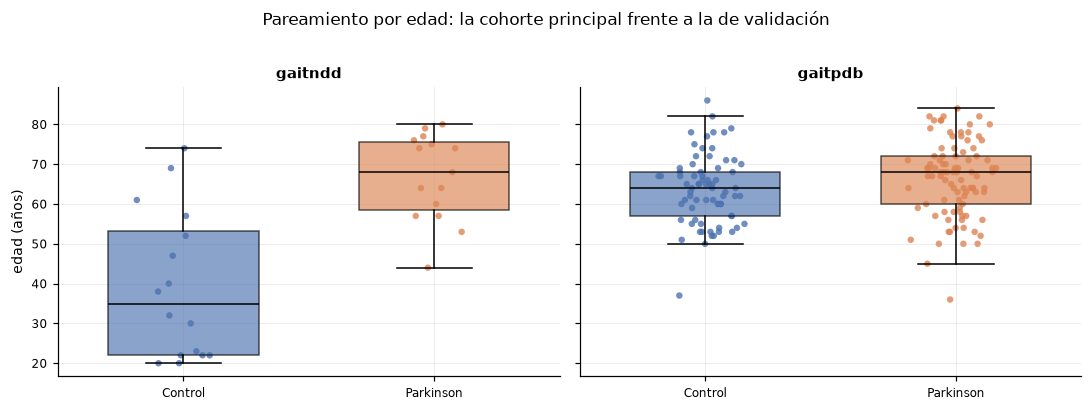

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6), sharey=True)
for ax, (titulo, tabla) in zip(axes, [("gaitndd", ndd_binario), ("gaitpdb", sujetos)]):
    plots.grouped_box(ax, tabla, "age", titulo, "edad (años)")
    plots.grouped_strip(ax, tabla, "age")
axes[1].set_ylabel("")
fig.suptitle("Pareamiento por edad: la cohorte principal frente a la de validación", y=1.02)
fig.tight_layout()
plots.save(fig, "pareamiento_edad_cohortes")

La figura muestra por qué el contraste importa: en `gaitndd` las cajas no se solapan siquiera, mientras que en `gaitpdb` prácticamente coinciden.

Esto convierte a `gaitpdb` en algo más que una prueba de generalización. Es el **instrumento para responder la pregunta de investigación 3**: si el eje Parkinson–control se sostiene aquí, la edad no era el mecanismo.

---

## 5. Grabaciones repetidas: el mismo problema de fuga, otra vez

In [16]:
por_sujeto = registros.groupby("subject").size().value_counts().sort_index()
por_sujeto.index.name = "caminatas por sujeto"
print(por_sujeto.to_string())
print()
print(registros.groupby(["study", "group"]).agg(
    grabaciones=("record", "size"),
    sujetos=("subject", "nunique"),
).assign(por_sujeto=lambda d: (d.grabaciones / d.sujetos).round(2)).to_string())

caminatas por sujeto
1    111
2     15
3     26
5      1
6      2
7     10

               grabaciones  sujetos  por_sujeto
study group                                    
Ga    control           38       18       2.110
      park              75       29       2.590
Ju    control           25       25       1.000
      park             104       29       3.590
Si    control           29       29       1.000
      park              35       35       1.000


**306 grabaciones provienen de 165 sujetos.** Cincuenta y cuatro sujetos aportan más de una caminata y los pacientes del estudio `Ju` aportan hasta siete.

El problema es idéntico al del cuaderno principal, pero más severo: dos caminatas del mismo paciente separadas por minutos son casi la misma observación. Tratarlas como independientes y partir aleatoriamente produciría la misma inflación de desempeño ya cuantificada en 19 puntos porcentuales.

La desproporción agrava el sesgo: en el estudio `Ju` los pacientes aportan 3.59 grabaciones cada uno y los controles solo 1. Un modelo entrenado sobre grabaciones vería una distribución de clases muy distinta de la real.

In [17]:
duraciones = []
for registro in registros.record:
    ruta_registro = config.GAITPDB.path / f"{registro}.txt"
    n_muestras = sum(1 for _ in ruta_registro.open())
    duraciones.append({"record": registro, "study": registro[:2], "duracion_s": n_muestras / gaitpdb.SAMPLING_HZ})

duraciones = pd.DataFrame(duraciones)
print(duraciones.groupby("study").duracion_s.agg(["count", "mean", "min", "max"]).round(1).to_string())

       count    mean     min     max
study                               
Ga       113 120.500  51.200 121.200
Ju       129  91.500  40.300 263.700
Si        64 121.200 121.200 121.200


Otra diferencia de protocolo entre estudios: `Ga` y `Si` tienen grabaciones de duración exactamente constante, mientras que las de `Ju` varían. Las series de longitud desigual obligan a normalizar por duración cualquier descriptor que dependa del número de zancadas.

---

## 6. La señal cruda

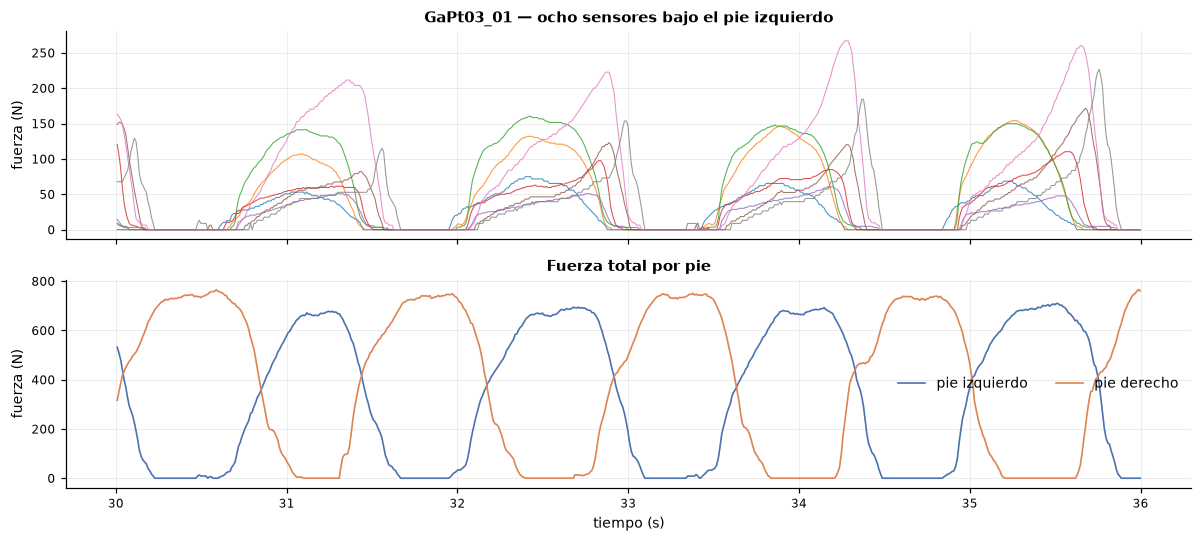

In [18]:
ejemplo = "GaPt03_01"
fuerzas = gaitpdb.read_forces(ejemplo)
ventana = fuerzas[(fuerzas.time_s >= 30) & (fuerzas.time_s < 36)]

fig, axes = plt.subplots(2, 1, figsize=(11, 5), sharex=True)
for i in range(1, 9):
    axes[0].plot(ventana.time_s, ventana[f"left_{i}"], lw=0.7, alpha=0.8)
axes[0].set_title(f"{ejemplo} — ocho sensores bajo el pie izquierdo")
axes[0].set_ylabel("fuerza (N)")

axes[1].plot(ventana.time_s, ventana.left_total, lw=1.1, color="#4C72B0", label="pie izquierdo")
axes[1].plot(ventana.time_s, ventana.right_total, lw=1.1, color="#DD8452", label="pie derecho")
axes[1].set_title("Fuerza total por pie")
axes[1].set_xlabel("tiempo (s)")
axes[1].set_ylabel("fuerza (N)")
axes[1].legend(ncols=2)

fig.tight_layout()
plots.save(fig, "gaitpdb_senal_vgrf")

El panel superior muestra la resolución espacial que `gaitndd` no tiene: los sensores del talón se activan antes que los del antepié dentro de cada apoyo. El panel inferior muestra la fuerza total por pie, de la que se derivan los eventos de contacto y despegue.

A diferencia de `gaitndd`, aquí **no hay una serie de zancadas preprocesada**: hay que detectar los eventos a partir de la señal. Eso es trabajo de P2, y tiene una ventaja: el criterio de detección queda bajo control explícito en lugar de heredarse de un algoritmo cuyos errores solo se descubren después, como ocurrió con las zancadas de 55 segundos del cuaderno principal.

In [19]:
velocidad = sujetos.groupby("group").speed_walk01.agg(["count", "mean", "std"])
velocidad.index = ["Control", "Parkinson"]
print("velocidad de marcha en la caminata normal (m/s):")
print(velocidad.round(3).to_string())

velocidad de marcha en la caminata normal (m/s):
           count  mean   std
Control       73 1.241 0.161
Parkinson     92 1.034 0.207


---

## 7. Síntesis

**Qué aporta esta cohorte.** 165 sujetos con señal (93 Parkinson, 72 control) frente a los 63 de `gaitndd`, con 16 canales de fuerza plantar en lugar de 2, y con grupos **pareados por edad y sexo**.

**Qué exige antes de usarse.** Un parser que tolere el número variable de tabuladores; normalización de la talla, que el estudio `Ju` reporta en centímetros; exclusión del sujeto huérfano `Juc010`; y exclusión de Hoehn & Yahr y UPDRS como predictores, por ser mediciones del propio diagnóstico.

**Qué particionamiento impone.** Agrupar por sujeto, igual que en la cohorte principal, y además estratificar o controlar por estudio de origen, porque los tres protocolos difieren y la razón de grabaciones por sujeto entre pacientes y controles no es la misma.

**Cómo se usa en P2.**

1. **Validación externa.** Entrenar el eje Parkinson–control en `gaitndd` y evaluarlo aquí, sin reajuste, para medir generalización a otro protocolo de captura.
2. **Control del confusor de edad.** Comparar el desempeño entre la cohorte confundida y la pareada. Una caída grande indicaría que parte del desempeño en `gaitndd` era demografía.
3. **Regresión de severidad.** Predecir UPDRS motor dentro del grupo de pacientes, donde deja de ser fuga y pasa a ser la variable objetivo.